# Univariate Feedback Prediction — TTC at Yellow Transition

**Goal:** For each event, use `TTC_min_at_yellow` (time-to-collision at the moment the light turns yellow)
to predict `time_to_feedback` — how many seconds after the yellow transition the driver gave feedback.

**Main output:** scatter plot of real data + regression model curve on the same axes.

**Input:** `output/windows_1s_clean.csv`  
**Output:** `output/events_yellow_ttc.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

import os

BASE_DIR    = os.path.dirname(os.path.abspath('__file__'))
INPUT_PATH  = os.path.join(BASE_DIR, 'output', 'windows_1s_clean.csv')
OUTPUT_PATH = os.path.join(BASE_DIR, 'output', 'events_yellow_ttc.csv')

df = pd.read_csv(INPUT_PATH)
print(f'Loaded: {len(df):,} rows, {len(df.columns)} columns')
print(f'Unique events: {df["event_id"].nunique():,}')

Loaded: 5,568 rows, 37 columns
Unique events: 183


## Step 1 — Build Event-Level Dataset

In [2]:
# ── Keep only events that have at least one yellow_transition == 1 window ──
events_with_yellow = df[df['yellow_transition'] == 1]['event_id'].unique()
df_yellow = df[df['event_id'].isin(events_with_yellow)].copy()

print(f'Events with yellow transition: {len(events_with_yellow):,}')
print(f'Windows in those events:       {len(df_yellow):,}')

# ── For each event, extract the TTC at the yellow-transition window ────────
yellow_rows = df_yellow[df_yellow['yellow_transition'] == 1].copy()

# If an event has multiple yellow windows (rare), take the first one
yellow_rows = yellow_rows.sort_values('start_time').groupby('event_id').first().reset_index()

ttc_at_yellow = yellow_rows.set_index('event_id')[['TTC_min', 'start_time']]
ttc_at_yellow.columns = ['TTC_min_at_yellow', 'yellow_start_time']

# ── For each event, extract feedback info ─────────────────────────────────
def get_feedback_info(event_df):
    fb_rows = event_df[event_df['first_feedback_relavet_to_event'] == 1]
    had_feedback = int(len(fb_rows) > 0)
    if had_feedback:
        fb_row = fb_rows.sort_values('start_time').iloc[0]
        return pd.Series({
            'first_feedback_relavet_to_event': 1,
            'feedback_time': fb_row['start_time'],
            'TrafficLight_at_feedback': fb_row['TrafficLight_current'],
        })
    else:
        return pd.Series({
            'first_feedback_relavet_to_event': 0,
            'feedback_time': np.nan,
            'TrafficLight_at_feedback': np.nan,
        })

feedback_info = df_yellow.groupby('event_id').apply(get_feedback_info).reset_index()

# ── Metadata: Id, Condition, Map ──────────────────────────────────────────
meta = df_yellow.groupby('event_id').first()[['Id', 'Condition', 'Map']].reset_index()

# ── Merge all together ────────────────────────────────────────────────────
events = meta.merge(ttc_at_yellow, on='event_id').merge(feedback_info, on='event_id')

print(f'\nEvent-level dataset: {len(events)} rows')
print(f'  With feedback (target=1): {events["first_feedback_relavet_to_event"].sum()}')
print(f'  Without feedback (target=0): {(events["first_feedback_relavet_to_event"]==0).sum()}')
print(f'  TTC NaN (no vehicle in front): {events["TTC_min_at_yellow"].isna().sum()}')

events.head(10)

Events with yellow transition: 144
Windows in those events:       4,739

Event-level dataset: 144 rows
  With feedback (target=1): 42.0
  Without feedback (target=0): 102
  TTC NaN (no vehicle in front): 0


,event_id,Id,Condition,Map,TTC_min_at_yellow,yellow_start_time,first_feedback_relavet_to_event,feedback_time,TrafficLight_at_feedback
0,C1_036248__Avatar__traffic light 1,C1_036248,Avatar,B,0.770795,21.0,0.0,NaN,NaN
1,C1_036248__Avatar__traffic light 2,C1_036248,Avatar,B,1.544321,15.0,0.0,NaN,NaN
2,C1_036248__Conventional__traffic light 1,C1_036248,Conventional,B,0.696154,12.0,1.0,14.0,Yellow
3,C1_036248__Conventional__traffic light 2,C1_036248,Conventional,B,1.709019,16.0,1.0,18.0,Yellow
4,C1_036248__Remote__traffic light 1,C1_036248,Remote,A,0.638560,12.0,0.0,NaN,NaN
5,C1_042566__Avatar__traffic light 1,C1_042566,Avatar,A,0.469565,17.0,0.0,NaN,NaN
6,C1_042566__Conventional__traffic light 1,C1_042566,Conventional,C,0.383113,15.0,1.0,16.0,Yellow
7,C1_042566__Conventional__traffic light 3,C1_042566,Conventional,C,1.461829,16.0,0.0,NaN,NaN
8,C1_042566__Remote__traffic light 1,C1_042566,Remote,B,0.802889,17.0,1.0,21.0,Red
9,C1_042566__Remote__traffic light 2,C1_042566,Remote,B,1.212899,14.0,1.0,19.0,Red


In [3]:
# Save event-level dataset
events.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')
print(f'Saved: {OUTPUT_PATH}')

Saved: C:\Users\ASUS VIVOBOOK\Desktop\אוניברסיטה\תואר שני\תזה\קוד\claude code\event relavent feedback\univariate_feedback_prediction\output\events_yellow_ttc.csv


## Step 2 — Compute time_to_feedback & Exploratory Analysis

In [4]:
# ── time_to_feedback: seconds from yellow transition to feedback ──────────
# feedback_time and yellow_start_time are both in time_since_event_start_world units
events['time_to_feedback'] = events['feedback_time'] - events['yellow_start_time']

# Events with feedback AND valid TTC — these are the modelling rows
model_df = events[
    events['first_feedback_relavet_to_event'].eq(1) &
    events['TTC_min_at_yellow'].notna()
].copy()

# Cap TTC at 99th percentile to reduce outlier influence on the plot
ttc_cap = events['TTC_min_at_yellow'].quantile(0.99)
model_df['TTC_capped'] = model_df['TTC_min_at_yellow'].clip(upper=ttc_cap)

print(f'Events with yellow transition:          {len(events)}')
print(f'  -> With feedback:                     {events["first_feedback_relavet_to_event"].sum()}')
print(f'  -> Without feedback:                  {(events["first_feedback_relavet_to_event"]==0).sum()}')
print(f'  -> TTC = NaN :   {events["TTC_min_at_yellow"].isna().sum()}')
print(f'\nModelling subset (feedback + TTC valid): {len(model_df)} events')
print(f'\ntime_to_feedback stats (seconds after yellow):')
print(model_df['time_to_feedback'].describe().round(3))
print(f'\nTTC_min_at_yellow stats (capped at {ttc_cap:.1f}s):')
print(model_df['TTC_capped'].describe().round(3))

Events with yellow transition:          144
  -> With feedback:                     42.0
  -> Without feedback:                  102
  -> TTC = NaN :   0

Modelling subset (feedback + TTC valid): 42 events

time_to_feedback stats (seconds after yellow):
count    42.000
mean      5.762
std       4.715
min       1.000
25%       2.000
50%       5.000
75%       6.750
max      22.000
Name: time_to_feedback, dtype: float64

TTC_min_at_yellow stats (capped at 2.2s):
count    42.000
mean      0.965
std       0.466
min       0.290
25%       0.624
50%       0.793
75%       1.358
max       2.191
Name: TTC_capped, dtype: float64


Pearson r (TTC vs time_to_feedback): r=0.293, p=0.0599


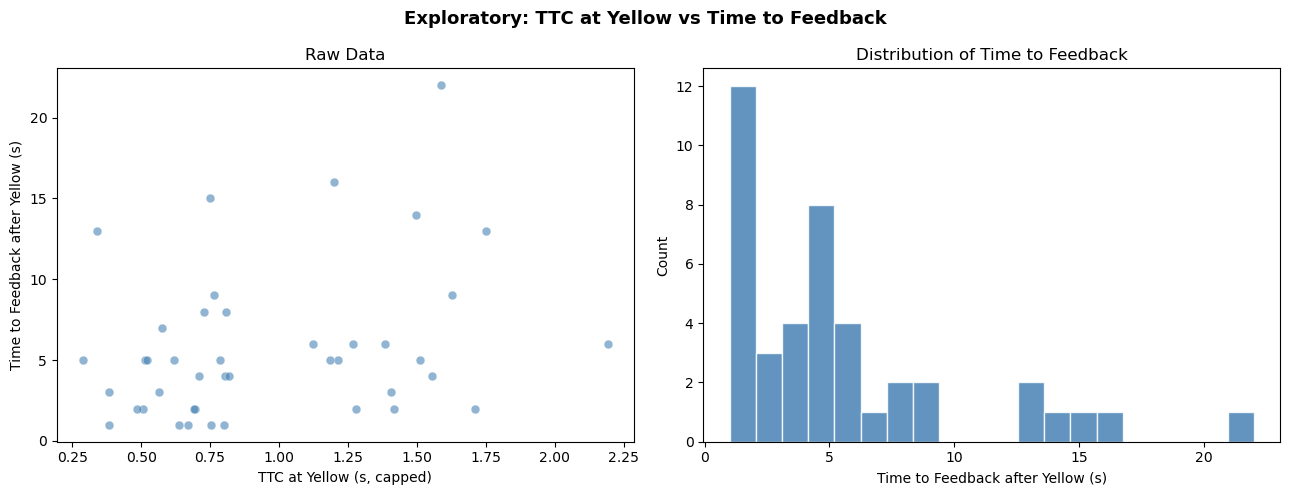

In [5]:
# ── Pearson correlation ───────────────────────────────────────────────────
r, pval = stats.pearsonr(model_df['TTC_capped'], model_df['time_to_feedback'])
print(f'Pearson r (TTC vs time_to_feedback): r={r:.3f}, p={pval:.4f}')

# ── Quick scatter to inspect the raw relationship ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Exploratory: TTC at Yellow vs Time to Feedback', fontsize=13, fontweight='bold')

# Left: scatter raw
ax = axes[0]
ax.scatter(model_df['TTC_capped'], model_df['time_to_feedback'],
           alpha=0.6, s=40, color='steelblue', edgecolors='white', linewidths=0.4)
ax.set_xlabel('TTC at Yellow (s, capped)')
ax.set_ylabel('Time to Feedback after Yellow (s)')
ax.set_title('Raw Data')

# Right: distribution of time_to_feedback
ax = axes[1]
ax.hist(model_df['time_to_feedback'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('Time to Feedback after Yellow (s)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Time to Feedback')

plt.tight_layout()
plt.show()

In [6]:
# Save event-level dataset (now includes time_to_feedback)
events.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')
print(f'Saved: {OUTPUT_PATH}')

Saved: C:\Users\ASUS VIVOBOOK\Desktop\אוניברסיטה\תואר שני\תזה\קוד\claude code\event relavent feedback\univariate_feedback_prediction\output\events_yellow_ttc.csv


## Step 3 — Linear Regression Model + Main Plot

In [7]:
X = model_df[['TTC_capped']].values
y = model_df['time_to_feedback'].values

reg = LinearRegression()
reg.fit(X, y)

y_pred = reg.predict(X)
r2   = r2_score(y, y_pred)
mae  = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f'Linear Regression: time_to_feedback = {reg.coef_[0]:.4f} * TTC + {reg.intercept_:.4f}')
print(f'  R²:   {r2:.3f}')
print(f'  MAE:  {mae:.3f}s')
print(f'  RMSE: {rmse:.3f}s')

Linear Regression: time_to_feedback = 2.9626 * TTC + 2.9040
  R²:   0.086
  MAE:  3.344s
  RMSE: 4.455s


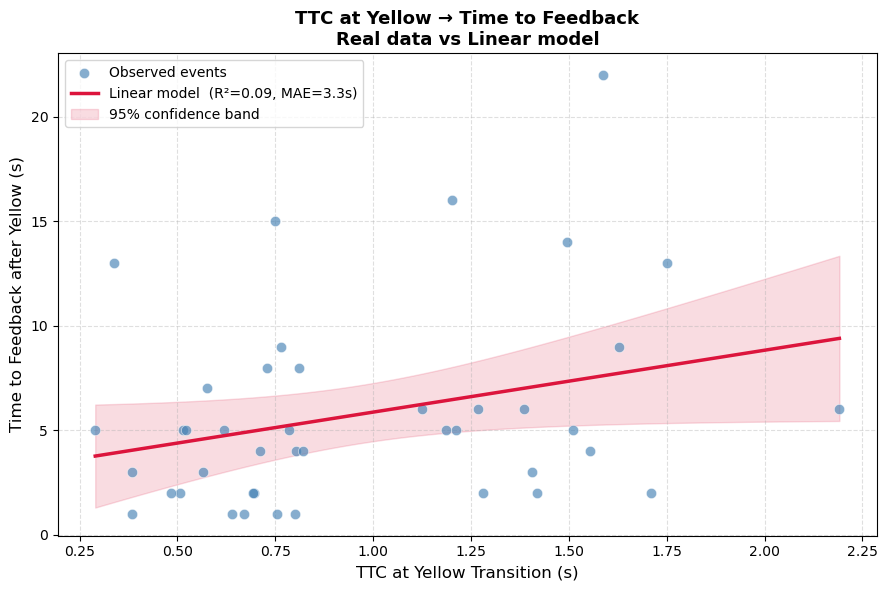

Plot saved.


In [8]:
# ── Main plot: real data + model line ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

# Scatter — real data points
ax.scatter(
    model_df['TTC_capped'], model_df['time_to_feedback'],
    alpha=0.65, s=55, color='steelblue', edgecolors='white', linewidths=0.5,
    label='Observed events', zorder=3
)

# Regression line
ttc_line = np.linspace(model_df['TTC_capped'].min(), model_df['TTC_capped'].max(), 300).reshape(-1, 1)
y_line   = reg.predict(ttc_line)
ax.plot(ttc_line, y_line, color='crimson', lw=2.5,
        label=f'Linear model  (R²={r2:.2f}, MAE={mae:.1f}s)', zorder=4)

# 95% confidence band (analytical)
n = len(model_df)
x_mean = model_df['TTC_capped'].mean()
ss_x   = ((model_df['TTC_capped'] - x_mean) ** 2).sum()
se     = rmse * np.sqrt(1/n + (ttc_line.ravel() - x_mean)**2 / ss_x)
t_crit = stats.t.ppf(0.975, df=n - 2)
ax.fill_between(ttc_line.ravel(),
                y_line - t_crit * se,
                y_line + t_crit * se,
                alpha=0.15, color='crimson', label='95% confidence band')

ax.set_xlabel('TTC at Yellow Transition (s)', fontsize=12)
ax.set_ylabel('Time to Feedback after Yellow (s)', fontsize=12)
ax.set_title('TTC at Yellow → Time to Feedback\nReal data vs Linear model', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'output', 'ttc_vs_time_to_feedback.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## Step 4 — Log Transform & Outlier Analysis

In [9]:
print('=' * 55)
print('  SUMMARY')
print('=' * 55)
print(f'Events with yellow transition:        {len(events)}')
print(f'  -> With feedback + TTC available:   {len(model_df)}')
print(f'  -> No feedback:                     {(events["first_feedback_relavet_to_event"]==0).sum()}')
print(f'  -> TTC = NaN (no vehicle):          {events["TTC_min_at_yellow"].isna().sum()}')
print(f'\nLinear model: time_to_feedback = {reg.coef_[0]:.4f} * TTC + {reg.intercept_:.4f}')
print(f'  Pearson r:  {r:.3f}  (p={pval:.4f})')
print(f'  R²:         {r2:.3f}')
print(f'  MAE:        {mae:.3f}s')
print(f'  RMSE:       {rmse:.3f}s')
print('=' * 55)

  SUMMARY
Events with yellow transition:        144
  -> With feedback + TTC available:   42
  -> No feedback:                     102
  -> TTC = NaN (no vehicle):          0

Linear model: time_to_feedback = 2.9626 * TTC + 2.9040
  Pearson r:  0.293  (p=0.0599)
  R²:         0.086
  MAE:        3.344s
  RMSE:       4.455s


In [10]:
# ── Define outlier threshold (1.5 * IQR rule) ────────────────────────────
Q1, Q3 = model_df['time_to_feedback'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outlier_threshold = Q3 + 1.5 * IQR

model_df['is_outlier'] = model_df['time_to_feedback'] > outlier_threshold
model_clean = model_df[~model_df['is_outlier']].copy()

print(f'Outlier threshold (Q3 + 1.5*IQR): {outlier_threshold:.2f}s')
print(f'Outliers removed: {model_df["is_outlier"].sum()} events')
print(f'Clean subset:     {len(model_clean)} events')

# ── Log-transform target ──────────────────────────────────────────────────
model_df['log_time_to_feedback']    = np.log(model_df['time_to_feedback'] + 1)
model_clean['log_time_to_feedback'] = np.log(model_clean['time_to_feedback'] + 1)

# ── Fit all 4 variants ────────────────────────────────────────────────────
def fit_and_score(x, y, label):
    reg = LinearRegression().fit(x.reshape(-1,1), y)
    y_pred = reg.predict(x.reshape(-1,1))
    r2   = r2_score(y, y_pred)
    mae  = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r, p = stats.pearsonr(x, y)
    print(f'{label:<45}  r={r:+.3f}  p={p:.4f}  R²={r2:.3f}  MAE={mae:.3f}')
    return reg, r2, mae, rmse, r, p

print(f'\n{"Model":<45}  {"r":>7}  {"p":>7}  {"R²":>6}  {"MAE":>7}')
print('-' * 80)
X_all   = model_df['TTC_capped'].values
X_clean = model_clean['TTC_capped'].values

reg_full,      r2_full,      mae_full,  rmse_full,  r_full,  p_full  = fit_and_score(X_all,   model_df['time_to_feedback'].values,    'Linear  | all data (original)')
reg_log_full,  r2_lf,        mae_lf,    rmse_lf,    r_lf,    p_lf    = fit_and_score(X_all,   model_df['log_time_to_feedback'].values, 'Linear  | all data (log Y)')
reg_clean,     r2_clean,     mae_clean, rmse_clean, r_clean, p_clean = fit_and_score(X_clean, model_clean['time_to_feedback'].values,  'Linear  | no outliers')
reg_log_clean, r2_lc,        mae_lc,    rmse_lc,    r_lc,    p_lc    = fit_and_score(X_clean, model_clean['log_time_to_feedback'].values, 'Linear  | no outliers (log Y)')

Outlier threshold (Q3 + 1.5*IQR): 13.88s
Outliers removed: 4 events
Clean subset:     38 events

Model                                                r        p      R²      MAE
--------------------------------------------------------------------------------
Linear  | all data (original)                  r=+0.293  p=0.0599  R²=0.086  MAE=3.344
Linear  | all data (log Y)                     r=+0.303  p=0.0515  R²=0.092  MAE=0.489
Linear  | no outliers                          r=+0.192  p=0.2472  R²=0.037  MAE=2.220
Linear  | no outliers (log Y)                  r=+0.225  p=0.1754  R²=0.050  MAE=0.430


In [12]:
# nbi-prompt: תסביר מה הקוד עושה
